In [18]:
%load_ext autoreload
%autoreload 2

import tifffile as tiff
from tifffile import imwrite
import platform
system = platform.system()
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sys

import os
from skimage.filters import try_all_threshold, threshold_otsu,  threshold_triangle, threshold_yen, threshold_li


sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *

system = platform.system()


if system == 'Linux':
    home = '/home/gerard/data/confocal/'
elif system == 'Darwin':
    home = '/Users/gerard/data/confocal/'
elif system == "Windows":
    home = 'C:/Users/cviko/data/confocal/'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
describe_acquisition(home + '2026_05_26_Gerardo/Project.lif', True)

TypeError: describe_acquisition() takes 1 positional argument but 2 were given

In [11]:
def fast_threshold_li(stack):
    s_min, s_max = float(stack.min()), float(stack.max())
    if s_max == s_min:
        return s_min
    u16 = ((stack - s_min) / (s_max - s_min) * 65535).astype(np.uint16)
    t_u16 = threshold_li(u16)
    return t_u16 / 65535 * (s_max - s_min) + s_min


def thresholding(date, user, series_list, deconv_iter_list, do_plot = True ):
    
    server = False
    system = platform.system()
    if system == 'Linux':
        if server:
            base_dir = '/home/gerard/ITB/home/data/confocal'
        else:
            base_dir = '/home/gerard/data/confocal'
        
    elif system == 'Darwin':
        if server:
            base_dir = '/Users/gerard/ITB/home/data/confocal'
        else:
            base_dir = '/Users/gerard/data/confocal'
        
    elif system == "Windows":
        base_dir = 'C:/Users/cviko/data/confocal/'
    
    info = describe_acquisition( base_dir + date + '_' + user + '/Project.lif', False)
    
    
    results = {}
    
    treshold_algorithm_list =[
    'triangle',
    'otsu',
    'yen',
    'li',
    ]
    
    
    for series in series_list:
        print(f'Processing series {series}---------------')
        results['s_'+str(series)] = {}
        
        channel_list = list(range(len(info[list(info.keys())[series]]['image_channels']))) 
        
        
        for channel in channel_list:
            results['s_'+str(series)]['c_'+str(channel)] = {}
            print(f'Channel {channel}************************')
            
            series_str = f'series_{series}'
            channel_str = f'channel_{channel}'
            
            base = os.path.join(base_dir,f'{date}_{user}',f'series_{series}', f'channel_{channel}')
            #path_series_channel = f'gerard/data/confocal/2026_05_26_Gerardo/series_{series}/channel_{channel}'#gerard/data/confocal/2026_05_26_Gerardo/Project.lif'
            #base = home + path_series_channel #os.path.join(home, )
            
            path_raw        = os.path.join(base, f'{date}_s{series}_ch{channel}.tif')
            path_raw_masks  = os.path.join(base, f'{date}_s{series}_ch{channel}_masks')
            
            
            for deconv_iter in deconv_iter_list:
            
                
                path_deconv      = os.path.join(base, f'{date}_s{series}_ch{channel}_deconv_iter_{deconv_iter}.tif')
                path_deconv_masks = os.path.join(base, f'{date}_s{series}_ch{channel}_deconv_iter_{deconv_iter}_masks')

                for path_in, path_out in [(path_raw, path_raw_masks), (path_deconv, path_deconv_masks)]:
                    
                    if 'deconv' in path_in:
                        deconv = True
                        key_dict = 'deconv_iter_'+str(deconv_iter)
                    else:
                            
                        deconv = False
                        key_dict = 'raw'
                    
                    print(key_dict, '************************')    
                    if not key_dict in results['s_'+str(series)]['c_'+str(channel)]:
                        results['s_'+str(series)]['c_'+str(channel)][key_dict] = {}

                    
                        with tiff.TiffFile(path_in) as tf:
                            stack = tf.asarray()
                            vxy = 1.0 / (tf.pages[0].tags['XResolution'].value[0] / tf.pages[0].tags['XResolution'].value[1])
                            vz  = tf.imagej_metadata['spacing']
                        
                        #stack_proj = stack.sum(axis=0)
                        stack_proj = stack.sum(axis=0).astype(np.float32)
    
                        results['s_'+str(series)]['c_'+str(channel)][key_dict]['stack'] = stack
                        results['s_'+str(series)]['c_'+str(channel)][key_dict]['stack_proj'] = stack_proj

                        for treshold_algorithm in treshold_algorithm_list:
                            results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm] = {}
                            
                        
                            if treshold_algorithm == 'triangle':
                                thresh = threshold_triangle(stack)
                                thresh_proj = threshold_triangle(stack_proj)
                            elif treshold_algorithm == 'otsu':
                                thresh = threshold_otsu(stack)
                                thresh_proj = threshold_otsu(stack_proj)
                            elif treshold_algorithm == 'yen':
                                thresh = threshold_yen(stack)
                                thresh_proj = threshold_yen(stack_proj) 
                            elif treshold_algorithm == 'li':
                                thresh = fast_threshold_li(stack)
                                thresh_proj = fast_threshold_li(stack_proj)
                            
                        

                            
                            #stack_flat = stack[stack > 0]
                            # pct_90 = np.percentile(stack_flat, 90)
                            # pct_95 = np.percentile(stack_flat, 95)
                            
                            print(f'treshold using {treshold_algorithm} = {thresh}')
                        
                            masks  = (stack > thresh).astype(np.uint8)
                            mask_proj = stack_proj > thresh_proj
                            
                            results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['threshold'] = thresh
                            results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['masks'] = masks
                            results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['mask_proj'] = mask_proj
                            


                            path_out_al = path_out + '_' + treshold_algorithm + '.tif'
                            imwrite(path_out_al, masks, imagej=True, resolution=(1/vxy, 1/vxy),
                                    metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})
                            
                            print(f'saved {path_out_al}')
                            
                        if do_plot:
                            plt.figure()
                            plt.hist(stack.ravel(), bins=256)
                            colors = [cm.tab10(i / len(treshold_algorithm_list)) for i in range(len(treshold_algorithm_list))]
                            
                            for i, thrsh_al in enumerate(treshold_algorithm_list):

                                # print(thrsh_al, '<------------')
                                thresh = results['s_'+str(series)]['c_'+str(channel)][key_dict][thrsh_al]['threshold']
                                plt.axvline(thresh, color=colors[i], linestyle='--', label=thrsh_al)
                            
                
                            
                            plt.legend(loc='upper right', title='Thresholds')
                            plt.title(f'series = {series}, channel = {channel}, {key_dict}')
                            # plt.axvline(pct_90, color='c', linestyle='--')
                            # plt.axvline(pct_95, color='m', linestyle='--')
                            
                            vmin, vmax = np.percentile(stack.ravel(), [1, 100])
                            plt.xlim(0,vmax)# stack.max())
                            plt.show()
    

In [12]:
thresholding('2026_05_26', 'Gerardo', [1], [4], do_plot = True )

TypeError: describe_acquisition() takes 1 positional argument but 2 were given

Processing series 1---------------
Channel 0************************
raw ************************
treshold using triangle = 31
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_triangle.tif
treshold using otsu = 17
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_otsu.tif
treshold using yen = 121
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_yen.tif
treshold using li = 13.102244257602296
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_li.tif


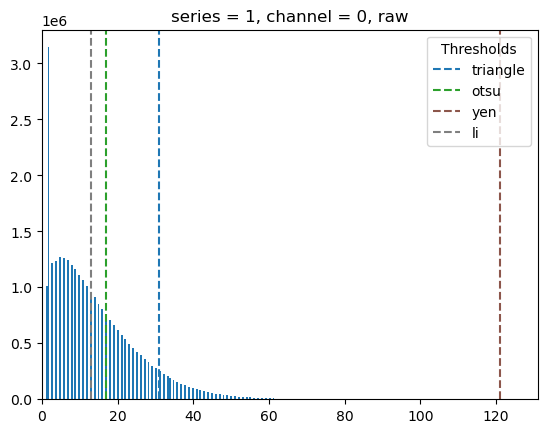

deconv_iter_4 ************************
treshold using triangle = 29.156204223632812
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_triangle.tif
treshold using otsu = 14.868310928344727
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_otsu.tif
treshold using yen = 26.14822769165039
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_yen.tif
treshold using li = 13.08954206459556
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_li.tif


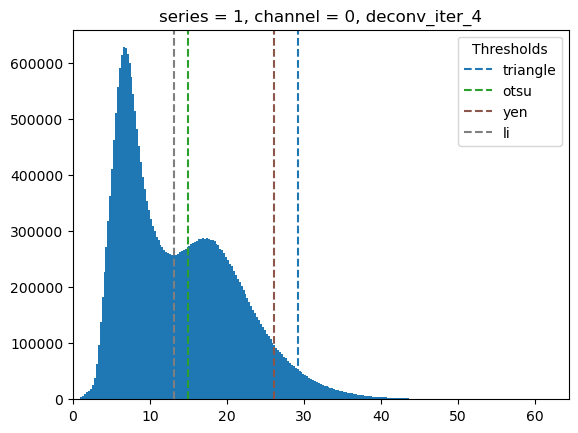

Channel 1************************
raw ************************
treshold using triangle = 3
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_triangle.tif
treshold using otsu = 11
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_otsu.tif
treshold using yen = 94
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_yen.tif
treshold using li = 4.991777710564051
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_li.tif


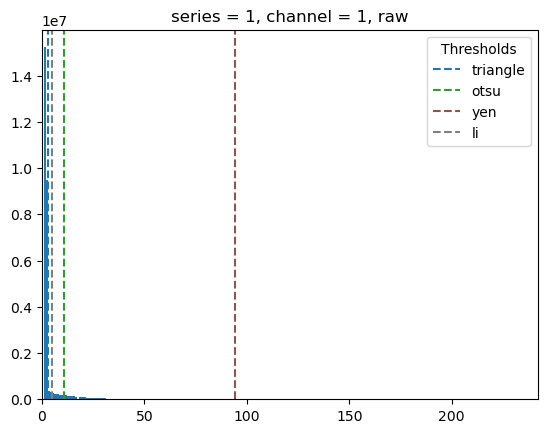

deconv_iter_4 ************************
treshold using triangle = 4.988361358642578
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_deconv_iter_4_masks_triangle.tif
treshold using otsu = 3.082674026489258
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_deconv_iter_4_masks_otsu.tif
treshold using yen = 8.946329116821289
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_deconv_iter_4_masks_yen.tif
treshold using li = 2.893326904668764
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_deconv_iter_4_masks_li.tif


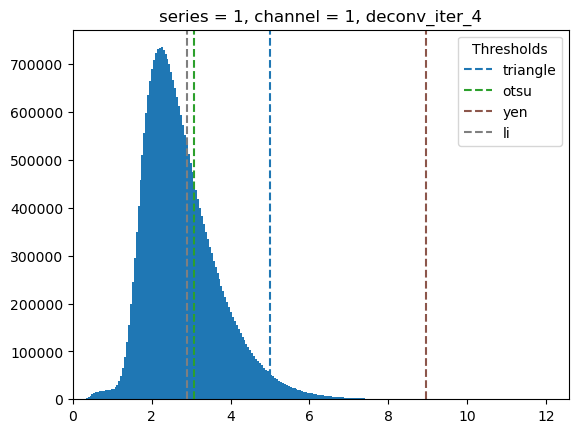

Channel 2************************
raw ************************
treshold using triangle = 17
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_masks_triangle.tif
treshold using otsu = 9
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_masks_otsu.tif
treshold using yen = 20
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_masks_yen.tif
treshold using li = 6.364036178844508
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_masks_li.tif


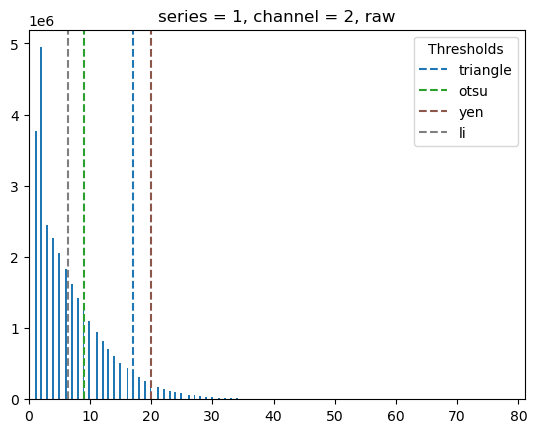

deconv_iter_4 ************************
treshold using triangle = 12.91905403137207
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_deconv_iter_4_masks_triangle.tif
treshold using otsu = 8.084770202636719
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_deconv_iter_4_masks_otsu.tif
treshold using yen = 45.68475341796875
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_deconv_iter_4_masks_yen.tif
treshold using li = 6.512702426230522
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_2/2026_05_26_s1_ch2_deconv_iter_4_masks_li.tif


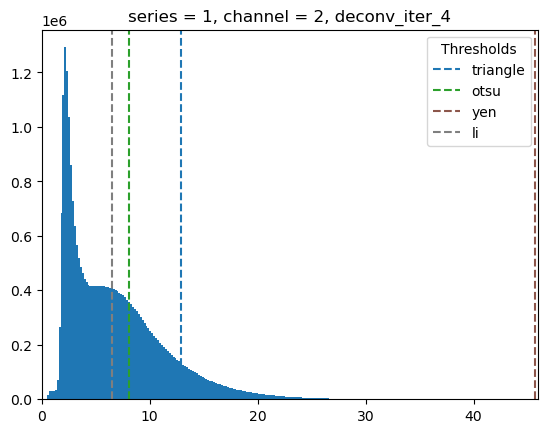

Processing series 2---------------
Channel 0************************
raw ************************
treshold using triangle = 3
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_masks_triangle.tif
treshold using otsu = 30
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_masks_otsu.tif
treshold using yen = 53
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_masks_yen.tif
treshold using li = 23.18685305631459
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_masks_li.tif


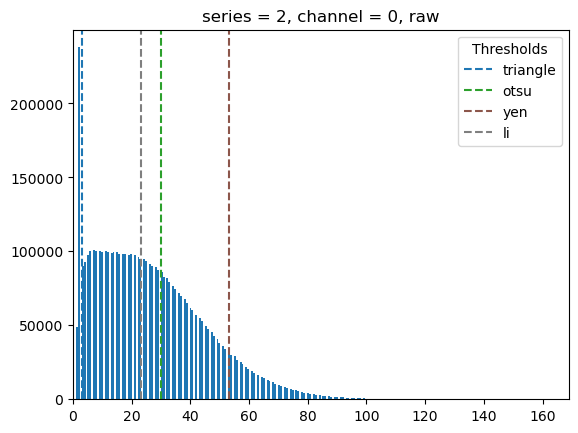

deconv_iter_4 ************************
treshold using triangle = 14.014583587646484
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_deconv_iter_4_masks_triangle.tif
treshold using otsu = 27.10018539428711
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_deconv_iter_4_masks_otsu.tif
treshold using yen = 33.43193054199219
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_deconv_iter_4_masks_yen.tif
treshold using li = 21.52261412040924
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_0/2026_05_26_s2_ch0_deconv_iter_4_masks_li.tif


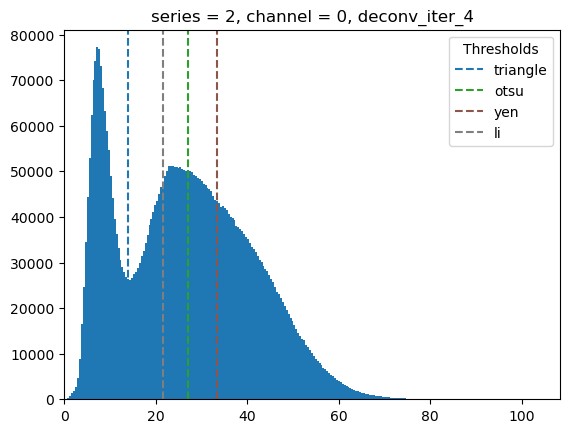

Channel 1************************
raw ************************
treshold using triangle = 3
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_masks_triangle.tif
treshold using otsu = 12
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_masks_otsu.tif
treshold using yen = 92
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_masks_yen.tif
treshold using li = 4.996542789612918
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_masks_li.tif


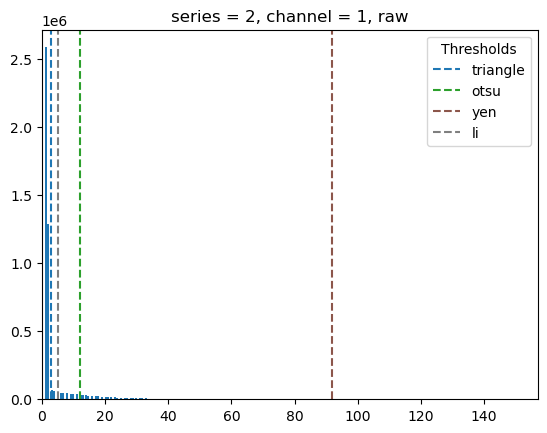

deconv_iter_4 ************************
treshold using triangle = 6.300258636474609
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_deconv_iter_4_masks_triangle.tif
treshold using otsu = 3.7267775535583496
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_deconv_iter_4_masks_otsu.tif
treshold using yen = 7.257833480834961
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_deconv_iter_4_masks_yen.tif
treshold using li = 3.4052889875083423
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_1/2026_05_26_s2_ch1_deconv_iter_4_masks_li.tif


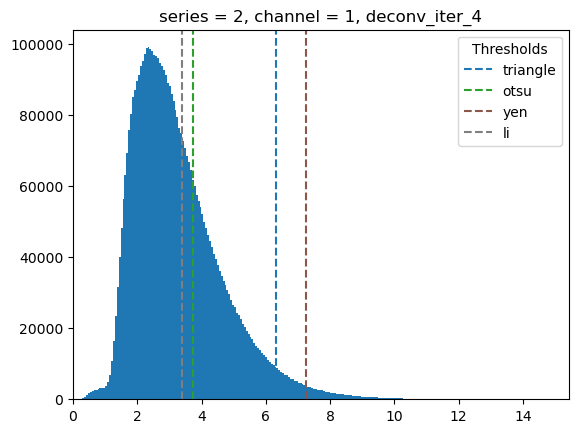

Channel 2************************
raw ************************
treshold using triangle = 12
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_masks_triangle.tif
treshold using otsu = 7
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_masks_otsu.tif
treshold using yen = 45
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_masks_yen.tif
treshold using li = 4.5040209264102105
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_masks_li.tif


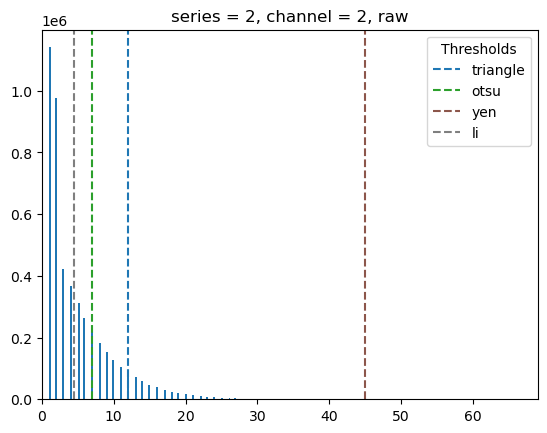

deconv_iter_4 ************************
treshold using triangle = 4.290096759796143
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_deconv_iter_4_masks_triangle.tif
treshold using otsu = 6.3411736488342285
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_deconv_iter_4_masks_otsu.tif
treshold using yen = 15.424514770507812
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_deconv_iter_4_masks_yen.tif
treshold using li = 5.026682124712311
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_2/channel_2/2026_05_26_s2_ch2_deconv_iter_4_masks_li.tif


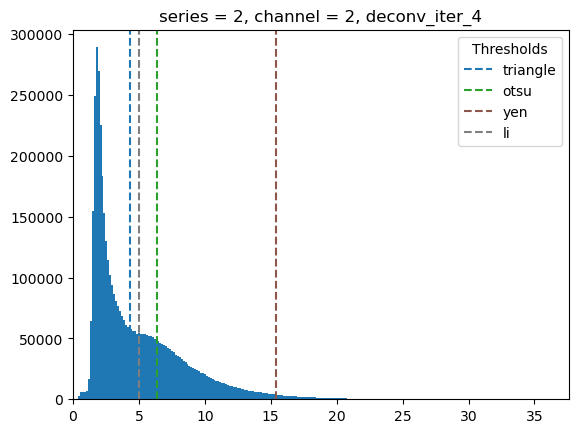

In [ ]:
treshold_algorithm_list =[
    'triangle',
    'otsu',
    'yen',
    'li',
]

series_list = [
  #  0,
    1,
   2,
    
]


channel_list = [
   0,
   1,
   2,
    
]
deconv_iter_list = [
    # 1,
    # 2,
    # 3,
   4,
    # 5,
    # 6,
    # 7,
    

]

results = {}

for series in series_list:
    print(f'Processing series {series}---------------')
    results['s_'+str(series)] = {}
    for channel in channel_list:
        results['s_'+str(series)]['c_'+str(channel)] = {}
        print(f'Channel {channel}************************')
        
        path_series_channel = f'gerard/data/confocal/2026_05_26_Gerardo/series_{series}/channel_{channel}'#gerard/data/confocal/2026_05_26_Gerardo/Project.lif'
        base = home + path_series_channel #os.path.join(home, )
        
        path_raw        = os.path.join(base, f'2026_05_26_s{series}_ch{channel}.tif')
        path_raw_masks  = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_masks')
        
        
        for deconv_iter in deconv_iter_list:
           
            
            path_deconv      = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_iter}.tif')
            path_deconv_masks = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_iter}_masks')

            for path_in, path_out in [(path_raw, path_raw_masks), (path_deconv, path_deconv_masks)]:
                
                if 'deconv' in path_in:
                    deconv = True
                    key_dict = 'deconv_iter_'+str(deconv_iter)
                else:
                        
                    deconv = False
                    key_dict = 'raw'
                
                print(key_dict, '************************')    
                if not key_dict in results['s_'+str(series)]['c_'+str(channel)]:
                    results['s_'+str(series)]['c_'+str(channel)][key_dict] = {}

                
                    with tiff.TiffFile(path_in) as tf:
                        stack = tf.asarray()
                        vxy = 1.0 / (tf.pages[0].tags['XResolution'].value[0] / tf.pages[0].tags['XResolution'].value[1])
                        vz  = tf.imagej_metadata['spacing']
                    
                    #stack_proj = stack.sum(axis=0)
                    stack_proj = stack.sum(axis=0).astype(np.float32)
 
                    results['s_'+str(series)]['c_'+str(channel)][key_dict]['stack'] = stack
                    results['s_'+str(series)]['c_'+str(channel)][key_dict]['stack_proj'] = stack_proj

                    for treshold_algorithm in treshold_algorithm_list:
                        results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm] = {}
                        
                    
                        if treshold_algorithm == 'triangle':
                            thresh = threshold_triangle(stack)
                            thresh_proj = threshold_triangle(stack_proj)
                        elif treshold_algorithm == 'otsu':
                            thresh = threshold_otsu(stack)
                            thresh_proj = threshold_otsu(stack_proj)
                        elif treshold_algorithm == 'yen':
                            thresh = threshold_yen(stack)
                            thresh_proj = threshold_yen(stack_proj) 
                        elif treshold_algorithm == 'li':
                            thresh = fast_threshold_li(stack)
                            thresh_proj = fast_threshold_li(stack_proj)
                        
                       

                        
                        #stack_flat = stack[stack > 0]
                        # pct_90 = np.percentile(stack_flat, 90)
                        # pct_95 = np.percentile(stack_flat, 95)
                        
                        print(f'treshold using {treshold_algorithm} = {thresh}')
                    
                        masks  = (stack > thresh).astype(np.uint8)
                        mask_proj = stack_proj > thresh_proj
                        
                        results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['threshold'] = thresh
                        results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['masks'] = masks
                        results['s_'+str(series)]['c_'+str(channel)][key_dict][treshold_algorithm]['mask_proj'] = mask_proj
                        


                        path_out_al = path_out + '_' + treshold_algorithm + '.tif'
                        imwrite(path_out_al, masks, imagej=True, resolution=(1/vxy, 1/vxy),
                                metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})
                        
                        print(f'saved {path_out_al}')
                        
                    
                    plt.figure()
                    plt.hist(stack.ravel(), bins=256)
                    colors = [cm.tab10(i / len(treshold_algorithm_list)) for i in range(len(treshold_algorithm_list))]
                    
                    for i, thrsh_al in enumerate(treshold_algorithm_list):

                        # print(thrsh_al, '<------------')
                        thresh = results['s_'+str(series)]['c_'+str(channel)][key_dict][thrsh_al]['threshold']
                        plt.axvline(thresh, color=colors[i], linestyle='--', label=thrsh_al)
                    
        
                    
                    plt.legend(loc='upper right', title='Thresholds')
                    plt.title(f'series = {series}, channel = {channel}, {key_dict}')
                    # plt.axvline(pct_90, color='c', linestyle='--')
                    # plt.axvline(pct_95, color='m', linestyle='--')
                    
                    vmin, vmax = np.percentile(stack.ravel(), [1, 100])
                    plt.xlim(0,vmax)# stack.max())
                    plt.show()

                    
                    
                
      



In [77]:
for k in (results['s_1']['c_0'].keys()):
    print(k)
    for subk in (results['s_1']['c_0'][k].keys()):
        print(f"    {subk}")
        try:
            for subkk in (results['s_1']['c_0'][k][subk].keys()):
                print(f"        {subkk}")
        except:
            pass

raw
    stack
    stack_proj
    triangle
        threshold
        masks
        mask_proj
    otsu
        threshold
        masks
        mask_proj
    yen
        threshold
        masks
        mask_proj
    li
        threshold
        masks
        mask_proj
deconv_iter_4
    stack
    stack_proj
    triangle
        threshold
        masks
        mask_proj
    otsu
        threshold
        masks
        mask_proj
    yen
        threshold
        masks
        mask_proj
    li
        threshold
        masks
        mask_proj


In [108]:


def compute_colocalization(dict_data, series, chA_n, chA_thrsh_al, chB_n, chB_thrsh_al, deconv_iter, min_val=500, do_plot=True):
   
    if deconv_iter != 0:
        deconv_str = 'deconv_iter_'+str(deconv_iter)
    else:
        deconv_str = 'raw'

    chA = dict_data['s_'+str(series)]['c_'+str(chA_n)][deconv_str]['stack']
    chB = dict_data['s_'+str(series)]['c_'+str(chB_n)][deconv_str]['stack']
    chA_proj = dict_data['s_'+str(series)]['c_'+str(chA_n)][deconv_str]['stack_proj']
    chB_proj = dict_data['s_'+str(series)]['c_'+str(chB_n)][deconv_str]['stack_proj']

    mask_chA = dict_data['s_'+str(series)]['c_'+str(chA_n)][deconv_str][chA_thrsh_al]['masks'].astype(bool)
    mask_chB = dict_data['s_'+str(series)]['c_'+str(chB_n)][deconv_str][chB_thrsh_al]['masks'].astype(bool)
    mask_chA_proj = dict_data['s_'+str(series)]['c_'+str(chA_n)][deconv_str][chA_thrsh_al]['mask_proj'].astype(bool)
    mask_chB_proj = dict_data['s_'+str(series)]['c_'+str(chB_n)][deconv_str][chB_thrsh_al]['mask_proj'].astype(bool)

    
    
    mask_union = mask_chA | mask_chB

    # per-frame Pearson R and Manders
    r_per_frame  = []
    M1_per_frame = []  # fraction of chA signal in chB-positive pixels
    M2_per_frame = []  # fraction of chB signal in chA-positive pixels

    for z in range(chA.shape[0]):
        chA_f, chB_f     = chA[z], chB[z]
        union_f          = mask_union[z]
        maskA_f, maskB_f = mask_chA[z], mask_chB[z]

        if union_f.sum() < min_val:
            r_per_frame.append(np.nan)
            M1_per_frame.append(np.nan)
            M2_per_frame.append(np.nan)
            continue

        r = np.corrcoef(chA_f[union_f], chB_f[union_f])[0, 1]
        r_per_frame.append(r)

        # M1: fraction of chA signal that falls in chB-positive pixels
        chA_total = chA_f[union_f].sum()
        M1 = chA_f[maskB_f].sum() / chA_total if chA_total > 0 else np.nan
        M1_per_frame.append(M1)

        # M2: fraction of chB signal that falls in chA-positive pixels
        chB_total = chB_f[union_f].sum()
        M2 = chB_f[maskA_f].sum() / chB_total if chB_total > 0 else np.nan
        M2_per_frame.append(M2)

    # sum-projection metrics (single value per stack)
    # chA_proj   = chA.sum(axis=0)
    # chB_proj   = chB.sum(axis=0)

    # threshold the sum projections directly — foreground = bright integrated across all frames
    # maskA_proj = chA_proj > fast_threshold_li(chA_proj)
    # maskB_proj = chB_proj > fast_threshold_li(chB_proj)
    # previous version (too permissive — foreground if above threshold in any single frame):
    # maskA_proj = mask_chA.any(axis=0)
    # maskB_proj = mask_chB.any(axis=0)

    union_proj = mask_chA_proj | mask_chB_proj

    r_sum = np.corrcoef(chA_proj[union_proj], chB_proj[union_proj])[0, 1]
    M1_sum = chA_proj[mask_chB_proj].sum() / chA_proj[union_proj].sum()
    M2_sum = chB_proj[mask_chA_proj].sum() / chB_proj[union_proj].sum()

    if do_plot:
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].plot(r_per_frame)
        axes[0].axhline(r_sum, color='r', linestyle='--', label=f'sum proj R={r_sum:.2f}')
        axes[0].set_title(f'Pearson R  ch{chA_n} vs ch{chB_n}')
        axes[0].set_xlabel('Frame'); axes[0].set_ylabel('R'); axes[0].legend()

        axes[1].plot(M1_per_frame)
        axes[1].axhline(M1_sum, color='r', linestyle='--', label=f'sum proj M1={M1_sum:.2f}')
        axes[1].set_title(f'M1: ch{chA_n} signal in ch{chB_n}-positive pixels')
        axes[1].set_xlabel('Frame'); axes[1].set_ylabel('M1'); axes[1].legend()

        axes[2].plot(M2_per_frame)
        axes[2].axhline(M2_sum, color='r', linestyle='--', label=f'sum proj M2={M2_sum:.2f}')
        axes[2].set_title(f'M2: ch{chB_n} signal in ch{chA_n}-positive pixels')
        axes[2].set_xlabel('Frame'); axes[2].set_ylabel('M2'); axes[2].legend()

        plt.suptitle(f'Series {series}  |  deconv iter {deconv_iter}  |  threshold algorithms: {chA_thrsh_al} (ch{chA_n}), {chB_thrsh_al} (ch{chB_n})')
        plt.tight_layout()
        plt.show()

    return {
        'r_per_frame':  r_per_frame,
        'M1_per_frame': M1_per_frame,
        'M2_per_frame': M2_per_frame,
        'r_sum':        r_sum,
        'M1_sum':       M1_sum,
        'M2_sum':       M2_sum,
    }

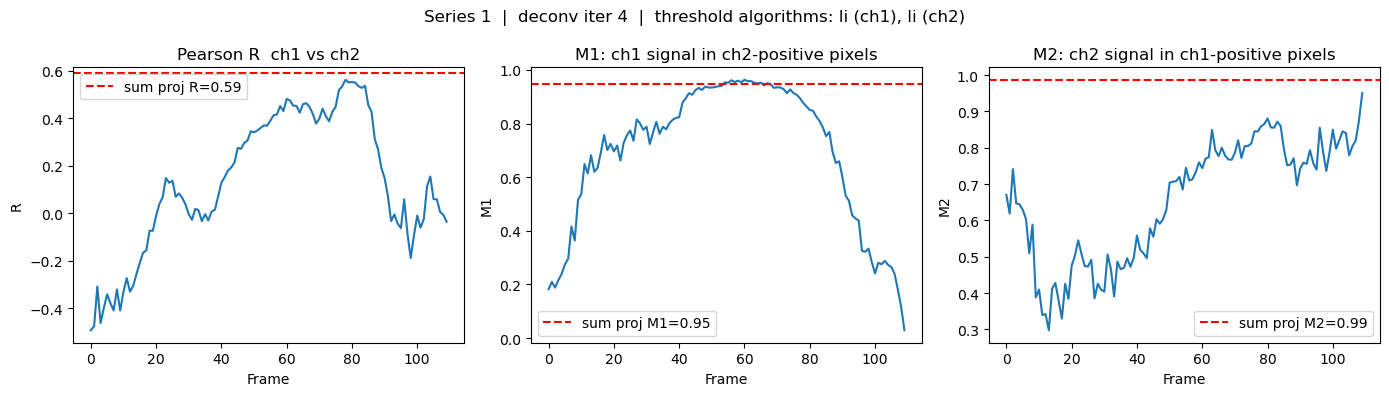

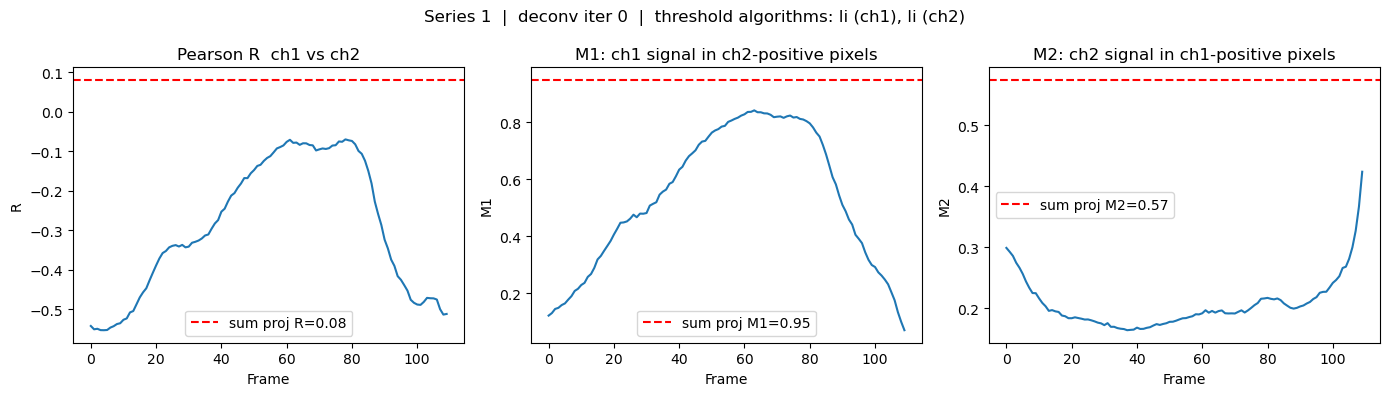

In [104]:
#def compute_colocalization(dict_data, series, chA_n, chA_thrsh_al, chB_n, chB_thrsh_al, deconv_iter, min_val=500, do_plot=True):
s1_coloc_1_2 = compute_colocalization(results, 1, 1,'li', 2,'li', 4,  min_val=500, do_plot=True)
s1_coloc_1_2 = compute_colocalization(results, 1, 1,'li', 2,'li', 0,  min_val=500, do_plot=True)

# s1_coloc_1_0 = compute_colocalization(results, 1, 1,'li', 0,'li', 4, min_val=500, do_plot=True)
# s1_coloc_2_0 = compute_colocalization(results, 1, 2,'li', 0,'li', 4, min_val=500, do_plot=True)

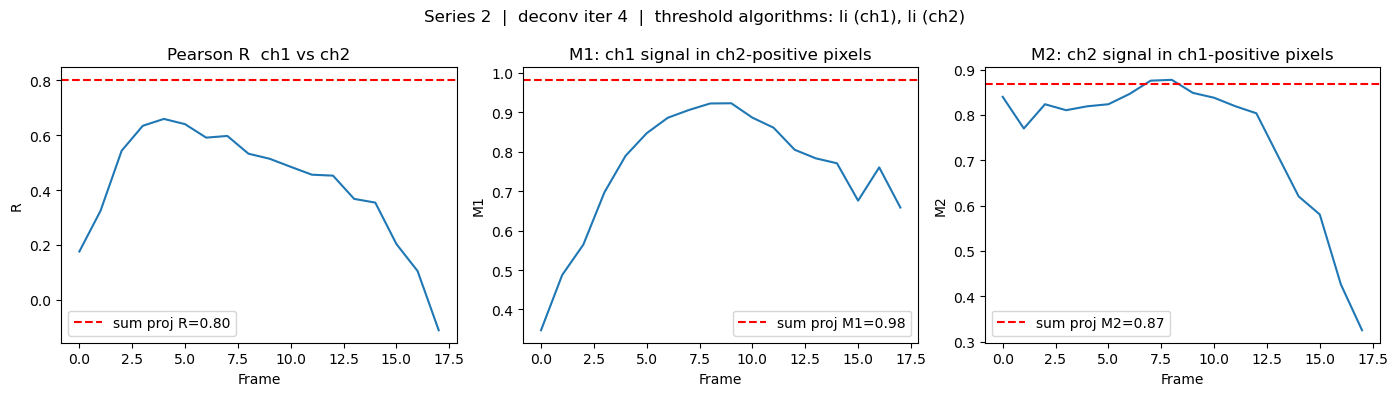

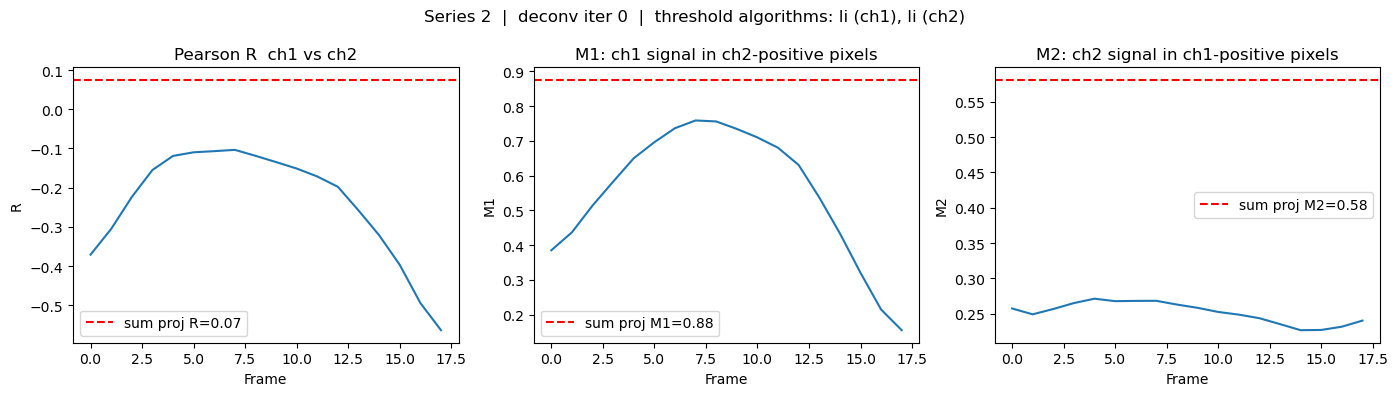

In [109]:
#def compute_colocalization(dict_data, series, chA_n, chA_thrsh_al, chB_n, chB_thrsh_al, deconv_iter, min_val=500, do_plot=True):
s2_coloc_1_2 = compute_colocalization(results, 2, 1,'li', 2,'li', 4,  min_val=500, do_plot=True)
s2_coloc_1_2 = compute_colocalization(results, 2, 1,'li', 2,'li', 0,  min_val=500, do_plot=True)